In [1]:
# More Decreasing Homicide Analysis
# Anita Sun

In [71]:
import pandas as pd
import geopandas as gpd
import shapely
from cartopy import crs
import seaborn as sns
import matplotlib.pyplot as plt
import re
from shapely.wkt import loads
import numpy as np

In [25]:
wave_metrics = pd.read_csv('wave_metrics.csv')
map_data = gpd.read_file('map_data.csv')
map_projects = gpd.read_file('map_projects.csv')
outliers = gpd.read_file('gap_outliers.csv')
top_amp = gpd.read_file('wave_amp_outliers.csv')
shapefile = gpd.read_file('Jada_Hexagons/hex_hom_bldg.shp')

In [26]:
map_data.geometry = map_data.geometry.apply(loads)
map_data = gpd.GeoDataFrame(map_data, geometry='geometry', crs="EPSG:4326")
outliers.geometry = outliers.geometry.apply(loads)
outliers = gpd.GeoDataFrame(outliers, geometry='geometry', crs="EPSG:4326")
top_amp.geometry = top_amp.geometry.apply(loads)
top_amp = gpd.GeoDataFrame(top_amp, geometry='geometry', crs="EPSG:4326")

In [30]:
commarea = gpd.read_file('comm_area_shapefiles/CHI Community Areas.shp')
commarea.geometry = commarea.geometry.to_crs(epsg=4326)

In [10]:
project_shapefile = gpd.read_file('cha_projects.geojson')

In [11]:
project_shapefile.head()

,name,yr_built_start,yr_built_end,yr_dmlsh_or_cnvrt_start,yr_dmlsh_or_cnvrt_end,units,id,geometry
0,Julia Lathrop,1938,NaN,2012.0,NaN,925,None,POINT (-87.67814 41.93229)
1,Cabrini Green,1942,NaN,1995.0,2010.0,3500,None,POINT (-87.64008 41.90046)
2,Henry Horner,1957,1963.0,1995.0,2008.0,920,None,POINT (-87.6767 41.8841)
3,Rockwell Gardens,1959,NaN,2000.0,2006.0,1126,None,POINT (-87.68938 41.87666)
4,Hilliard Towers,1966,NaN,2006.0,NaN,654,None,POINT (-87.63015 41.8552)


In [36]:
map_projects = map_data.sjoin(project_shapefile, how='inner')

In [5]:
wave_metrics.head()

,Unnamed: 0,GRID_ID,wave_group,wave_lifespan,wave_amplitude,wave_start_year,wave_decade,wave_end_year,max_amp,min_amp
0,0,AA-10,1,1,3,1928,1920,1929,6,3
1,1,AA-10,2,1,5,1975,1970,1976,6,3
2,2,AA-10,3,2,5,1980,1980,1982,6,3
3,3,AA-10,4,2,4,1984,1980,1986,6,3
4,4,AA-10,5,5,6,1989,1980,1994,6,3


In [70]:
map_projects.head()

,field_1,GRID_ID,year,hom_ct,bldg_ct,hom_rt,geometry,last_wave_end,longest_gap,index_right,name,yr_built_start,yr_built_end,yr_dmlsh_or_cnvrt_start,yr_dmlsh_or_cnvrt_end,units,id
17,17,AM-36,1874,0.0,0.0,,"POLYGON ((-87.59165 41.65495, -87.59466 41.649...",2007.0,10.0,16,Altgeld Gardens,1945,NaN,NaN,NaN,1500,None
139,139,AI-29,1874,0.0,0.0,,"POLYGON ((-87.6277 41.72779, -87.63071 41.7225...",1994.0,23.0,14,Lowden Homes,1952,NaN,NaN,NaN,127,None
279,279,AJ-21,1874,0.0,0.0,,"POLYGON ((-87.61869 41.81624, -87.62169 41.811...",2012.0,5.0,13,Robert Taylor,1961,NaN,1998.0,2007.0,4415,None
293,293,AI-20,1874,0.0,3.80644355802387,0.0,"POLYGON ((-87.6277 41.82145, -87.63071 41.8162...",2017.0,0.0,9,Wentworth Gardens,1945,NaN,NaN,NaN,344,None
294,294,AJ-20,1874,0.0,4.735893981097023,0.0,"POLYGON ((-87.61869 41.82665, -87.62169 41.821...",2015.0,2.0,10,Stateway Gardens,1955,1958.0,2001.0,2007.0,1644,None


In [43]:
map_projects['longest_gap'] = map_projects['longest_gap'].astype(float)

In [81]:
for col in map_projects.columns:
    try:
        map_projects[col] = map_projects[col].astype(float)
    except:
        pass

In [82]:
map_projects['yr_dmlsh_or_cnvrt_end'].value_counts()

yr_dmlsh_or_cnvrt_end
2007.0    268
2011.0    268
2006.0    134
2008.0    134
2010.0    134
Name: count, dtype: int64

In [87]:
map_projects['last_wave_end'].mode()

0    1994.0
Name: last_wave_end, dtype: float64

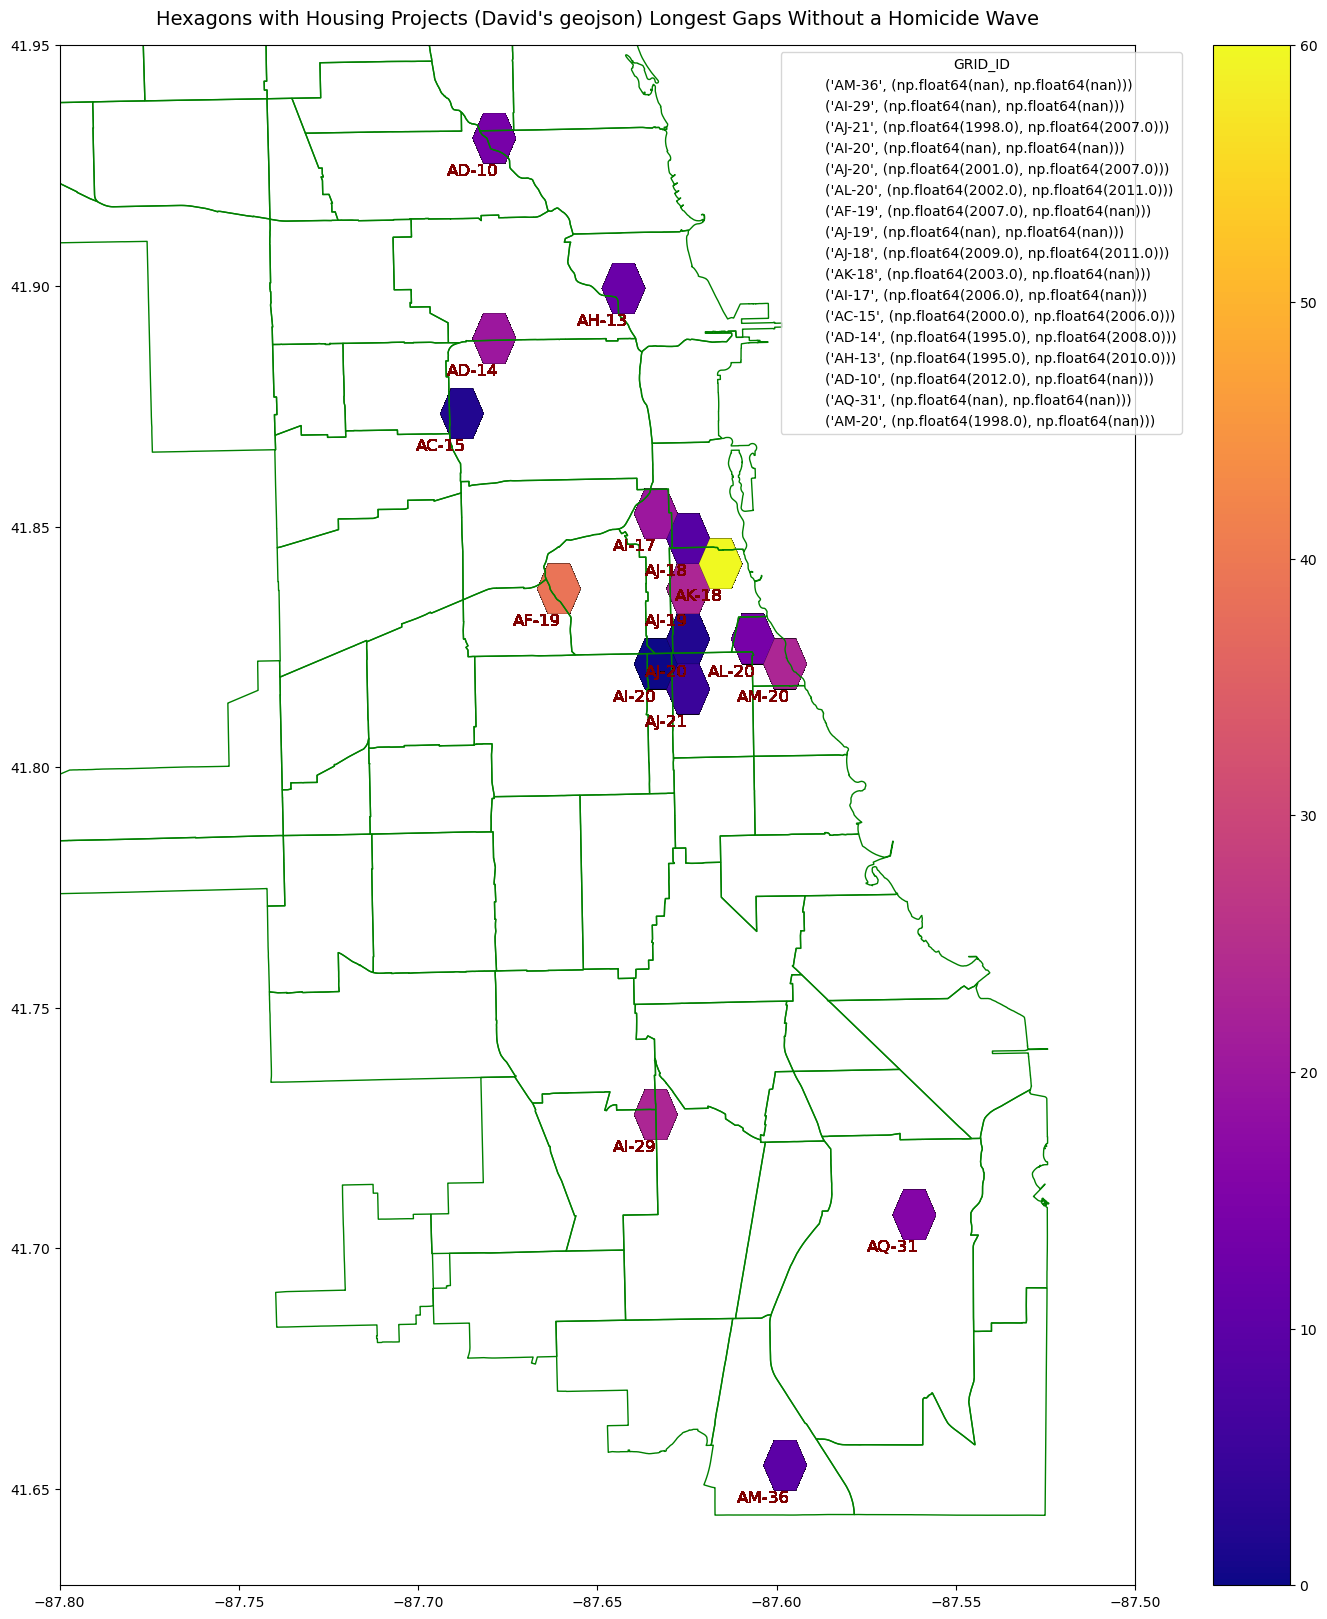

In [88]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(20, 20))

# Plot all hexagons colored by longest_gap
map_projects.plot(column="longest_gap", cmap="plasma", edgecolor="black", linewidth=0.1, legend=True, ax=ax,)
ax.set_title("Hexagons with Housing Projects (David's geojson) Longest Gaps Without a Homicide Wave", fontsize=14, pad=15)
#ax.annotate("Note: Hexagons where bldg_ct = 0 have been excluded in this visualization", xy=(0.5, -0.1), xycoords="axes fraction", ha="center", fontsize=10)

plt.xlim(-87.8, -87.5)
plt.ylim(41.63, 41.95)

# Plot community boundaries

commarea.plot(facecolor="none", edgecolor="green", linewidth=1, ax=ax)

# Add community labels

for geo, label in zip(map_projects.geometry,
                        map_projects.GRID_ID):
    x_min, y_min, x_max, y_max = geo.bounds
    ax.text(x_min, y_min, label, 
             fontsize=12, color='maroon' , ha="center", va="top", weight="light", wrap=True)
'''
for x, y, label in zip(commarea.geometry.centroid.x, 
                        commarea.geometry.centroid.y, 
                        commarea["COMMUNITY"]):
    ax.text(x, y, label, fontsize=6, color="white", ha="center", va="center")'''

legend = []

for i in map_projects['GRID_ID'].unique():
    sub_map = map_projects[map_projects['GRID_ID']==i]
    dmlsh_start = sub_map['yr_dmlsh_or_cnvrt_start'].max() if sub_map['yr_dmlsh_or_cnvrt_start'].max() != np.nan else 'None'
    dmlsh_end = sub_map['yr_dmlsh_or_cnvrt_end'].max() if sub_map['yr_dmlsh_or_cnvrt_end'].max() != np.nan else 'None'

    legend.append((i, (dmlsh_start, dmlsh_end)))

handles = [plt.Line2D([0], [0], linestyle='', label=grid_id) for grid_id in legend]
plt.legend(handles=handles, fontsize=10, title="GRID_ID", bbox_to_anchor=(1.05, 1), loc='upper right')

plt.savefig('viz/projects_longest_gaps_real.png')

plt.show()